# Part 1: 시뮬레이션 DGP 설계와 데이터 탐색

이 노트북에서는 MTA(Multi-Touch Attribution) 방법론 비교를 위한 시뮬레이션 데이터의 설계 과정과 생성된 데이터의 특성을 탐색한다.

## 목차
1. 문제 정의와 시뮬레이션의 필요성
2. DGP 학술 프레임워크 통합
3. 채널 구조와 전이 행렬
4. 유저 세그먼트와 여정 생성
5. 전환 모델 라이브 데모
6. 생성 데이터 EDA
7. Ground Truth 해석

In [1]:
import json, sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sys.path.insert(0, os.path.abspath('../..'))
from part1_simulation import CHANNEL_NAMES, SEGMENT_NAMES
from part1_simulation.config_loader import load_dgp_config
from part1_simulation.dgp.channel_config import build_transition_matrices, CHANNEL_TO_IDX
from part1_simulation.dgp.user_segments import assign_segments
from part1_simulation.dgp.conversion_model import (
    compute_log_intensity, compute_temporal_decay, intensity_to_conversion_prob,
    compute_cross_influence_bonus,
)
from part1_simulation.notebook_setup import setup_notebook, METHOD_CATEGORIES, CATEGORY_COLORS
setup_notebook()

config = load_dgp_config(overrides=['alpha_0=-5.625'])
print(f"DGP Config loaded: {config.n_users:,} users, {config.n_channels} channels")

DGP Config loaded: 100,000 users, 7 channels


## 1. 문제 정의: 왜 시뮬레이션인가?

MTA 방법론을 비교하려면 **"실제 기여도"(ground truth)** 가 알려져 있어야 한다. 그러나 공개 데이터셋에는 근본적 한계가 있다:

| 데이터셋 | 한계 |
|---------|------|
| **Criteo Attribution (2018)** | 16.5M 이벤트이나 모든 feature가 해시/익명화 → 도메인 해석 불가 |
| **GA4 BigQuery** | traffic_source가 세션별이 아닌 first-touch 고정 → 멀티터치 시퀀스 재구성 불가 |
| **CriteoPrivateAd (2025)** | uuid가 일 단위 리셋 → 멀티데이 여정 구성 원천 불가 |

**결론:** "해석 가능한 feature + ground truth + 멀티터치 시퀀스"를 갖춘 공개 데이터셋은 존재하지 않는다. → **시뮬레이션이 유일한 대안.**

## 2. DGP 학술 프레임워크 통합

MTA 시뮬레이션의 DGP를 독자적으로 설계하는 대신, 학술적으로 검증된 **3편의 논문**을 기반으로 구축했다. 각 논문이 다루는 현실의 다른 측면을 결합함으로써, 단일 프레임워크보다 풍부한 데이터 구조를 얻는다.

---

### 2.1 [Primary] Du et al. (2019) — JD.com / Stanford GSB

**논문:** *"Causally Driven Incremental Multi Touch Attribution Using a Recurrent Neural Network"* (AdKDD 2019)

**채택 요소:**
- **기본 골격:** 유저(i) × 채널(k) × 시간(t) 구조. 유저별 순차적(sequential) 광고 노출과 전환 결정을 모델링
- **유저 이질성 (User Heterogeneity):** 유저 고유 특성 $d_i$를 도입. 본 프로젝트에서는 이를 3개 세그먼트(New/Exploratory/Loyal)의 $\eta$ 파라미터로 구현
- **Confounding 구조:** 세그먼트가 채널 노출 확률과 전환 확률에 동시 영향 → selection bias 자연 발생
- **Incremental Shapley:** 전체 전환이 아닌 **순증 전환(incremental conversion)**만 배분하는 인과적 Shapley Value 제안

**본 프로젝트 구현:**
- 세그먼트별 시작 채널 선호: New → Display/Social, Loyal → Email/Direct
- $\eta$ 파라미터: New(-0.3), Exploratory(0.0), Loyal(+0.5) → 전환 확률에 직접 영향
- 이 구조가 실험 05(Correlational vs Causal)의 confounding 메커니즘

---

### 2.2 [Secondary] Shender et al. (2023) — Google Research

**논문:** *"A Time To Event Framework For Multi-touch Attribution"* (Journal of Data Science, Vol.22)

**채택 요소:**
- **Log-linear Intensity Model:** 전환을 비동질 포아송 과정(inhomogeneous Poisson process)으로 모델링. 전환 "강도" $\lambda_i(t)$를 광고 노출의 함수로 정의
- **채널별 시간 감쇠 (Temporal Decay):** 광고 효과가 시간에 따라 감쇠하는 패턴을 $f(t - t_j) = \exp(-\Delta t / \text{half\_life})$로 채널마다 다르게 설정
- **AICPE Attribution:** 경로에서 광고를 순차적으로 제거하며 전환 확률 변화를 측정하는 반사실적 기여도 산출

**본 프로젝트 구현:**
- Display: half-life **14일** (느린 감쇠 — 2주에 걸친 인지 효과)
- Paid Search: half-life **1일** (빠른 감쇠 — 검색 의도는 당일 소멸)
- Email: half-life **5일** (중간 — 열람 후 5일 정도 효과 지속)
- 이 차별화된 감쇠가 Time Decay 방법론과 Survival/Poisson 방법론의 성능 차이를 만든다

---

### 2.3 [Complementary] CDA Framework (2025)

**논문:** *"Causal-driven attribution (CDA): Estimating channel influence without user-level data"* (ArXiv 2512.21211)

**채택 요소:**
- **채널 간 교차 영향 (Cross-Channel Influence):** 특정 채널의 노출이 다른 채널의 전환 기여에 영향. 예를 들어, Display를 본 후 Paid Search를 클릭하면 전환 확률이 추가로 상승하는 **시너지 효과**
- **현실적 시나리오 근거:** 논문에서 "2년간의 탐색 끝에도 적절한 공개 데이터셋을 찾을 수 없었다"고 보고 — 본 프로젝트의 시뮬레이션 접근과 동일한 문제 인식

**본 프로젝트 구현:**
- Display → Paid Search: $\delta = 0.4$ (인지 → 검색 전환 시너지, **가장 강함**)
- Social → Email: $\delta = 0.3$ (관심 유발 → 리텐션 채널 시너지)
- Organic Search → Direct: $\delta = 0.2$ (정보 탐색 → 브랜드 기억 시너지)
- source가 target보다 **먼저 등장한 경우에만 활성화** (방향성 있는 시너지)
- 이 파라미터가 실험 02(Interaction Effect)에서 방법론별 시너지 탐지 능력을 테스트하는 기준

---

### 2.4 통합 전환 강도 모델

세 프레임워크의 요소를 하나의 수식으로 결합:

$$\log(\lambda_i(t)) = \underbrace{\alpha_0}_{\text{baseline}} + \underbrace{\sum_j \sum_k \beta_k \cdot x_{jk} \cdot f_{\text{channel}_k}(t - t_j)}_{\text{Shender et al.: 채널 효과 × 시간 감쇠}} + \underbrace{\sum_{(s,t)} \delta_{st} \cdot f_{\text{source}}(\Delta t) \cdot \mathbb{1}[\text{source before target}]}_{\text{CDA: 교차 영향 × source 감쇠}} + \underbrace{\eta_{\text{segment}_i}}_{\text{Du et al.: 유저 이질성}}$$

$$P(\text{conversion}) = 1 - \exp\left(-\exp(\log \lambda)\right) \quad \text{(Poisson process realization)}$$

> **교차 영향 감쇠:** source 채널의 시너지 효과도 시간에 따라 감쇠한다. $\delta_{\text{eff}} = \delta_{st} \times f_{\text{source}}(\Delta t)$. 예를 들어 Display(t½=14일) → Paid Search의 경우, 96시간 경과 시 $\delta_{\text{eff}} = 0.4 \times 0.751 = 0.301$로 약 25% 감쇠한다.

이 수식의 **모든 파라미터가 알려져 있으므로**, 각 채널의 "진짜 기여도"를 정확히 계산할 수 있다. 이것이 Ground Truth이며, 18개 방법론의 평가 기준이 된다.

### 2.5 알려진 단순화와 한계

세 프레임워크를 통합하면서 다음의 단순화가 적용되었다. 이들은 연구 결론의 방향성에는 영향을 주지 않지만, 결과 해석 시 인지해야 한다.

**1. δ는 log-hazard scale에서 정의됨 (Issue A)**

Cross-influence δ가 log(λ)에 가법적으로 더해지는 구현은, λ-space에서의 승법적 결합과 수학적으로 동치이다:

$$\exp(\log\lambda + \delta) = \exp(\log\lambda) \times \exp(\delta)$$

따라서 δ=0.4는 "source→target 시 hazard rate가 $\exp(0.4) \approx 1.49$배, 즉 **약 49% 증가**"를 의미한다. Shender et al.의 Poisson 프레임워크와 일관적이다.

**2. 여정 길이 효과가 η를 압도할 수 있음 (Issue C)**

세그먼트별 전환율은 η만으로 결정되지 않는다. Exploratory 세그먼트(η=0.0)가 Loyal(η=+0.5)보다 높은 전환율을 보일 수 있는데, 이는 Exploratory의 긴 여정(평균 7개 터치포인트)이 후반부에 고-β 채널(Paid Search, Email)을 더 많이 축적하기 때문이다.

이는 **버그가 아닌 emergent property**이다. 현실에서도 더 많은 터치포인트를 가진 유저가 전환할 가능성이 높으며, 단순히 "충성 유저"라고 전환이 보장되지 않는다. 다만 실험 05(Correlational vs Causal)의 confounding 해석 시 이 점을 고려해야 한다.

**3. 전이 행렬과 β가 독립적으로 설정됨 (Issue D)**

채널 전이 확률(어떤 순서로 채널을 방문하는가)과 채널 효과(β, 각 채널의 전환 강도)는 **별도의 메커니즘**으로 설정되어 있다. 현실에서도 유저의 채널 탐색 패턴과 각 채널의 광고 효과는 독립적으로 결정되므로, 이는 **의도된 설계**이다. 다만, β를 변경하면 전이 행렬도 재검토가 필요하다.

**4. Ground Truth 분해의 β-비례 배분 (Design Decision)**

Ground Truth A에서 교차 영향 δ의 credit을 source/target에 배분할 때, 50-50이 아닌 **β 비율**로 나눈다:

$$\text{source share} = \frac{\beta_{\text{source}}}{\beta_{\text{source}} + \beta_{\text{target}}}$$

예: Display(β=0.3) → Paid Search(β=1.2)의 경우, Display는 시너지 credit의 **20%**, Paid Search는 **80%**를 받는다. 이는 전환 강도에 대한 실제 영향력(β)에 비례하는 배분으로, 50-50보다 인과적으로 합리적이다.

In [2]:
# 채널 파라미터 테이블
channel_df = pd.DataFrame([
    {"Channel": ch.name, "β (effect)": ch.beta, "Decay Half-life (days)": ch.decay_half_life_days, "Funnel Position": ch.funnel_position}
    for ch in config.channels
]).set_index("Channel")
print("=== 7채널 DGP 파라미터 ===")
display(channel_df) if hasattr(__builtins__, '__IPYTHON__') else print(channel_df)

print("\n=== Cross-Influence (채널 간 시너지) ===")
for ci in config.cross_influences:
    print(f"  {ci.source} → {ci.target}: δ = {ci.delta}")

print("\n=== 유저 세그먼트 ===")
for seg in config.segments:
    print(f"  {seg.name} ({seg.proportion:.0%}): η={seg.eta:+.1f}, "
          f"journey~Geom({seg.geometric_p})+{seg.geometric_offset}, "
          f"start={seg.start_channels}")

print("\n=== Cross-Influence Temporal Decay Demo ===")
print("Display → Paid Search (δ=0.4, Display half-life=14d):")
for gap_h in [24, 96, 200]:
    decay = compute_temporal_decay(14.0, gap_h)
    delta_eff = 0.4 * decay
    print(f"  Δt={gap_h:3d}h → f_source={decay:.4f}, δ_eff={delta_eff:.4f} ({(1-decay)*100:.0f}% decayed)")

=== 7채널 DGP 파라미터 ===


,β (effect),Decay Half-life (days),Funnel Position
Channel,,,
Display,0.3,14.0,upper
Social,0.4,3.0,upper
Organic Search,0.5,7.0,mid
Paid Search,1.2,1.0,lower
Email,0.8,5.0,mid
Referral,0.5,7.0,mid
Direct,0.7,2.0,lower



=== Cross-Influence (채널 간 시너지) ===
  Display → Paid Search: δ = 0.4
  Social → Email: δ = 0.3
  Organic Search → Direct: δ = 0.2

=== 유저 세그먼트 ===
  New (50%): η=-0.3, journey~Geom(0.25)+1, start=('Display', 'Social')
  Exploratory (30%): η=+0.0, journey~Geom(0.2)+2, start=('Organic Search',)
  Loyal (20%): η=+0.5, journey~Geom(0.5)+1, start=('Email', 'Direct')

=== Cross-Influence Temporal Decay Demo ===
Display → Paid Search (δ=0.4, Display half-life=14d):
  Δt= 24h → f_source=0.9311, δ_eff=0.3724 (7% decayed)
  Δt= 96h → f_source=0.7515, δ_eff=0.3006 (25% decayed)
  Δt=200h → f_source=0.5514, δ_eff=0.2206 (45% decayed)


### DGP 인과 구조 (Causal DAG)

아래 DAG는 본 시뮬레이션의 **데이터 생성 메커니즘**을 인과 그래프로 표현한다:

- **빨간 점선 (Confounding Path):** User Segment가 채널 노출(Start Channel)과 전환 확률(η)에 동시에 영향 → selection bias 생성. 이것이 Causal 방법론이 필요한 근본 원인.
- **검정 화살표:** 데이터 생성의 인과 흐름. 채널 시퀀스 → 시간 감쇠 적용 → cross-influence 반영 → log-intensity 합산 → 전환 결정.
- **색상 범례:** 각 노드의 학술적 출처 (Du et al. / Shender et al. / CDA)를 색상으로 구분.

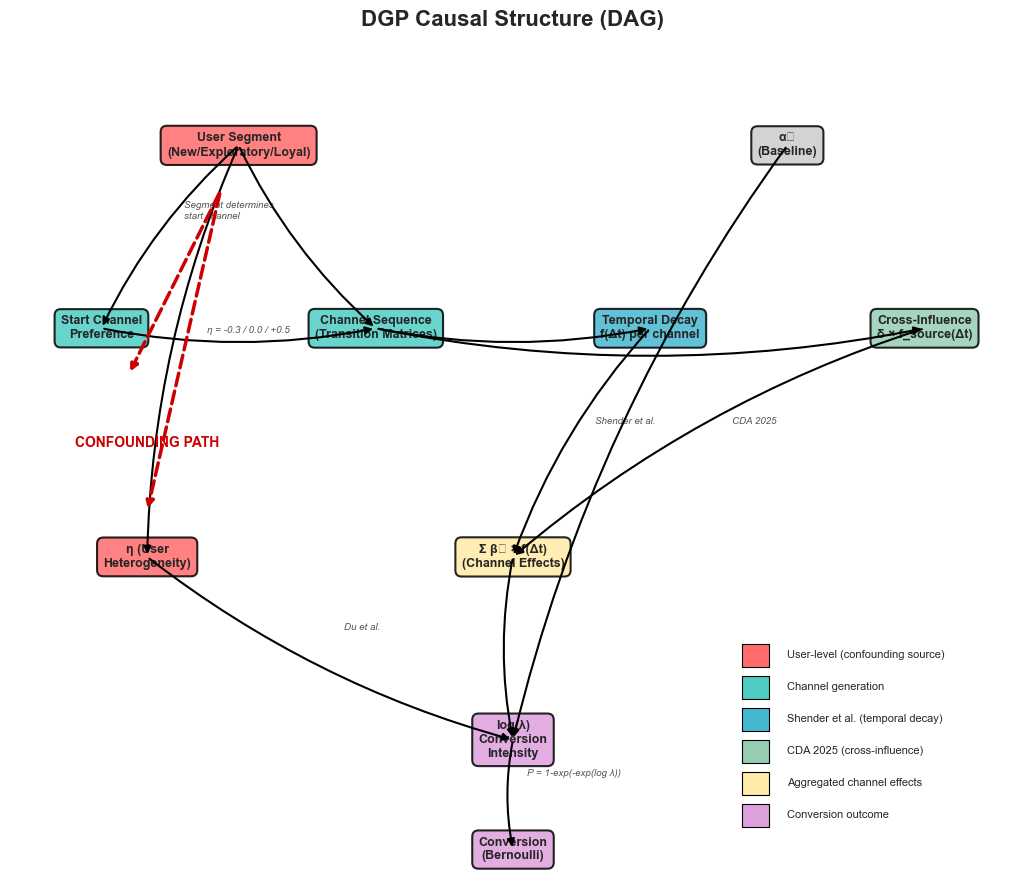

In [3]:
## DGP Causal DAG (Directed Acyclic Graph)

fig, ax = plt.subplots(figsize=(14, 9))
ax.set_xlim(-0.5, 10.5)
ax.set_ylim(-0.5, 8.5)
ax.set_aspect('equal')
ax.axis('off')

# --- Node positions ---
nodes = {
    # Exogenous
    "User Segment\n(New/Exploratory/Loyal)":  (2, 7.5),
    "α₀\n(Baseline)":                          (8, 7.5),
    # Channel layer
    "Start Channel\nPreference":               (0.5, 5.5),
    "Channel Sequence\n(Transition Matrices)":  (3.5, 5.5),
    "Temporal Decay\nf(Δt) per channel":        (6.5, 5.5),
    "Cross-Influence\nδ × f_source(Δt)":    (9.5, 5.5),
    # Core
    "η (User\nHeterogeneity)":                 (1, 3),
    "Σ βₖ × f(Δt)\n(Channel Effects)":          (5, 3),
    # Outcome
    "log(λ)\nConversion\nIntensity":            (5, 1),
    "Conversion\n(Bernoulli)":                  (5, -0.2),
}

node_colors = {
    "User Segment\n(New/Exploratory/Loyal)":  "#FF6B6B",
    "α₀\n(Baseline)":                          "#CCCCCC",
    "Start Channel\nPreference":               "#4ECDC4",
    "Channel Sequence\n(Transition Matrices)":  "#4ECDC4",
    "Temporal Decay\nf(Δt) per channel":        "#45B7D1",
    "Cross-Influence\nδ × f_source(Δt)":    "#96CEB4",
    "η (User\nHeterogeneity)":                 "#FF6B6B",
    "Σ βₖ × f(Δt)\n(Channel Effects)":          "#FFEAA7",
    "log(λ)\nConversion\nIntensity":            "#DDA0DD",
    "Conversion\n(Bernoulli)":                  "#DDA0DD",
}

# Draw nodes
for label, (x, y) in nodes.items():
    color = node_colors[label]
    bbox = dict(boxstyle="round,pad=0.5", facecolor=color, edgecolor="black", linewidth=1.5, alpha=0.85)
    ax.text(x, y, label, ha="center", va="center", fontsize=9, fontweight="bold", bbox=bbox)

# --- Edges (arrows) ---
edges = [
    # Segment → confounding paths
    ("User Segment\n(New/Exploratory/Loyal)", "Start Channel\nPreference",        "Segment determines\nstart channel"),
    ("User Segment\n(New/Exploratory/Loyal)", "η (User\nHeterogeneity)",           "η = -0.3 / 0.0 / +0.5"),
    ("User Segment\n(New/Exploratory/Loyal)", "Channel Sequence\n(Transition Matrices)", ""),
    # Channel generation
    ("Start Channel\nPreference",             "Channel Sequence\n(Transition Matrices)", ""),
    ("Channel Sequence\n(Transition Matrices)","Temporal Decay\nf(Δt) per channel",      ""),
    ("Channel Sequence\n(Transition Matrices)","Cross-Influence\nδ × f_source(Δt)",   ""),
    # → Intensity
    ("Temporal Decay\nf(Δt) per channel",     "Σ βₖ × f(Δt)\n(Channel Effects)",         "Shender et al."),
    ("Cross-Influence\nδ × f_source(Δt)", "Σ βₖ × f(Δt)\n(Channel Effects)",         "CDA 2025"),
    ("Σ βₖ × f(Δt)\n(Channel Effects)",       "log(λ)\nConversion\nIntensity",           ""),
    ("η (User\nHeterogeneity)",               "log(λ)\nConversion\nIntensity",           "Du et al."),
    ("α₀\n(Baseline)",                        "log(λ)\nConversion\nIntensity",           ""),
    # → Conversion
    ("log(λ)\nConversion\nIntensity",         "Conversion\n(Bernoulli)",                 "P = 1-exp(-exp(log λ))"),
]

for src, dst, label in edges:
    x1, y1 = nodes[src]
    x2, y2 = nodes[dst]
    ax.annotate("",
        xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle="-|>", color="black", lw=1.5,
                        connectionstyle="arc3,rad=0.1"),
    )
    if label:
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        ax.text(mx + 0.15, my + 0.2, label, fontsize=7, fontstyle="italic", color="#555555")

# Confounding annotation
ax.annotate("CONFOUNDING PATH",
    xy=(1, 4.2), fontsize=10, color="#CC0000", fontweight="bold",
    ha="center",
)
ax.annotate("",
    xy=(0.8, 5.0), xytext=(1.8, 7.0),
    arrowprops=dict(arrowstyle="-|>", color="#CC0000", lw=2.5, linestyle="--"),
)
ax.annotate("",
    xy=(1.0, 3.5), xytext=(1.8, 7.0),
    arrowprops=dict(arrowstyle="-|>", color="#CC0000", lw=2.5, linestyle="--"),
)

# Legend
legend_items = [
    ("#FF6B6B", "User-level (confounding source)"),
    ("#4ECDC4", "Channel generation"),
    ("#45B7D1", "Shender et al. (temporal decay)"),
    ("#96CEB4", "CDA 2025 (cross-influence)"),
    ("#FFEAA7", "Aggregated channel effects"),
    ("#DDA0DD", "Conversion outcome"),
]
for i, (color, desc) in enumerate(legend_items):
    ax.add_patch(plt.Rectangle((7.5, 1.8 - i * 0.35), 0.3, 0.25, facecolor=color, edgecolor="black", linewidth=0.8))
    ax.text(8.0, 1.93 - i * 0.35, desc, fontsize=8, va="center")

ax.set_title("DGP Causal Structure (DAG)", fontsize=16, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

## 3. 채널 구조와 위치 의존적 전이 행렬

마케팅 여정은 퍼널 구조를 따른다: 인지(upper) → 고려(mid) → 전환(lower). 이를 반영하기 위해 여정 위치에 따라 3개의 전이 확률 행렬을 설계했다:

- **Early** (position ≤ 0.3): Display/Social 우세 → Organic/Referral로 전이
- **Mid** (0.3 < position ≤ 0.7): 균등 탐색, Organic Search 중심
- **Late** (position > 0.7): Paid Search/Email/Direct로 수렴 (전환 채널)

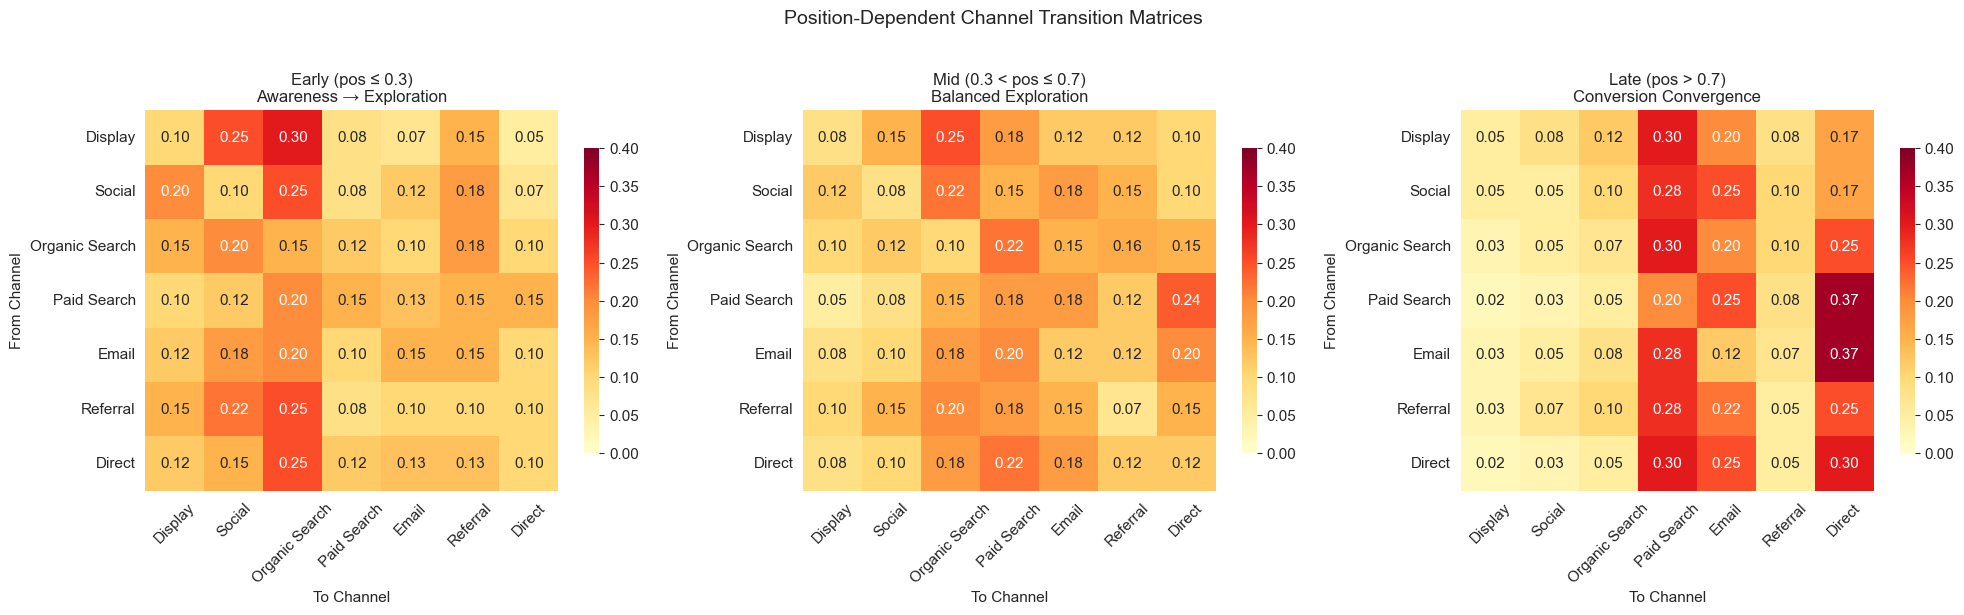

early: Paid Search col avg=0.104, Direct col avg=0.096
late: Paid Search col avg=0.277, Direct col avg=0.269


In [4]:
matrices = build_transition_matrices(config)
channels = list(CHANNEL_NAMES)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
titles = {"early": "Early (pos ≤ 0.3)\nAwareness → Exploration",
          "mid": "Mid (0.3 < pos ≤ 0.7)\nBalanced Exploration",
          "late": "Late (pos > 0.7)\nConversion Convergence"}

for ax, (regime, matrix) in zip(axes, matrices.items()):
    sns.heatmap(matrix, annot=True, fmt=".2f", cmap="YlOrRd",
                xticklabels=channels, yticklabels=channels,
                ax=ax, vmin=0, vmax=0.4, cbar_kws={"shrink": 0.8})
    ax.set_title(titles[regime], fontsize=12)
    ax.set_xlabel("To Channel")
    ax.set_ylabel("From Channel")
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle("Position-Dependent Channel Transition Matrices", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 퍼널 진행 확인: late 행렬에서 Paid Search/Direct 열 평균
for regime in ["early", "late"]:
    m = matrices[regime]
    paid_avg = m[:, CHANNEL_TO_IDX["Paid Search"]].mean()
    direct_avg = m[:, CHANNEL_TO_IDX["Direct"]].mean()
    print(f"{regime}: Paid Search col avg={paid_avg:.3f}, Direct col avg={direct_avg:.3f}")

## 4. 유저 세그먼트와 여정 생성

3개 세그먼트는 Du et al. (2019)의 user heterogeneity를 구현:

| 세그먼트 | 비율 | 특성 | η (이질성) | 여정 길이 |
|---------|------|------|----------|----------|
| **New** | 50% | Display/Social에서 시작, 긴 탐색 여정 | -0.3 (전환 어려움) | ~5 터치포인트 |
| **Exploratory** | 30% | Organic Search 중심, 정보 탐색 | 0.0 (중립) | ~7 터치포인트 |
| **Loyal** | 20% | Email/Direct 중심, 짧은 여정 | +0.5 (전환 쉬움) | ~3 터치포인트 |

이 세그먼트 구조가 **confounding**을 생성한다: Loyal 유저는 Email을 많이 받고 전환율도 높다. Email이 좋아서인가, Loyal이어서인가? → Causal 방법론의 존재 이유.

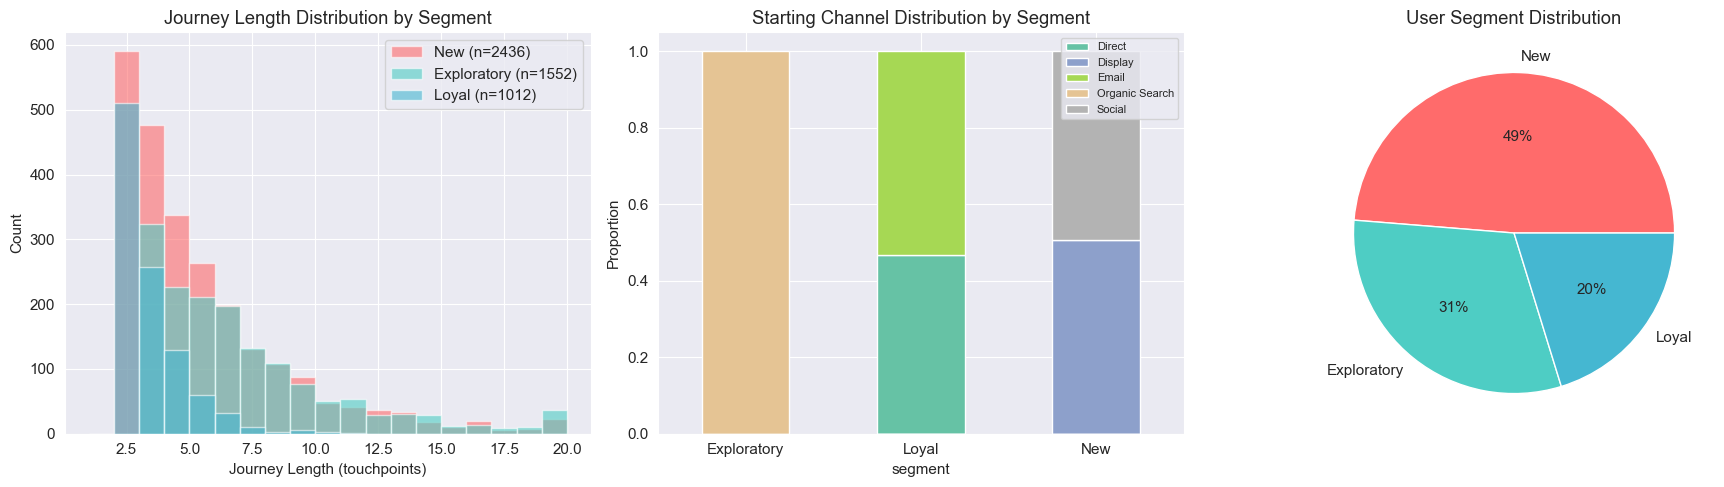

평균 여정 길이: New=5.0, Exploratory=6.7, Loyal=3.0
전체 skewness: 1.84 (right-skewed)


In [5]:
rng = np.random.default_rng(42)
users = assign_segments(5000, config.segments, config.max_touchpoints, rng)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 여정 길이 분포
for seg_name, color in zip(["New", "Exploratory", "Loyal"], ["#FF6B6B", "#4ECDC4", "#45B7D1"]):
    subset = users[users["segment"] == seg_name]
    axes[0].hist(subset["journey_length"], bins=range(1, 21), alpha=0.6, label=f"{seg_name} (n={len(subset)})", color=color, edgecolor="white")
axes[0].set_xlabel("Journey Length (touchpoints)")
axes[0].set_ylabel("Count")
axes[0].set_title("Journey Length Distribution by Segment")
axes[0].legend()

# 시작 채널 분포
start_counts = users.groupby(["segment", "start_channel"]).size().unstack(fill_value=0)
start_counts.div(start_counts.sum(axis=1), axis=0).plot(kind="bar", stacked=True, ax=axes[1], colormap="Set2")
axes[1].set_title("Starting Channel Distribution by Segment")
axes[1].set_ylabel("Proportion")
axes[1].legend(fontsize=8, loc="upper right")
axes[1].tick_params(axis='x', rotation=0)

# 세그먼트 비율
seg_counts = users["segment"].value_counts()
axes[2].pie(seg_counts, labels=seg_counts.index, autopct="%1.0f%%", colors=["#FF6B6B", "#4ECDC4", "#45B7D1"])
axes[2].set_title("User Segment Distribution")

plt.tight_layout()
plt.show()

print(f"평균 여정 길이: New={users[users['segment']=='New']['journey_length'].mean():.1f}, "
      f"Exploratory={users[users['segment']=='Exploratory']['journey_length'].mean():.1f}, "
      f"Loyal={users[users['segment']=='Loyal']['journey_length'].mean():.1f}")
print(f"전체 skewness: {users['journey_length'].skew():.2f} (right-skewed)")

## 5. 전환 모델 라이브 데모

예시 여정: **Display(t=0h) → Organic Search(t=48h) → Paid Search(t=96h)**

이 여정에 대해 log-intensity의 각 구성 요소를 분해하여 시각화한다.

=== Touchpoint별 기여 분해 ===
            Touchpoint      β  Δt (hours)  Decay f(Δt)  β × f(Δt)
        Display (t=0h) 0.3000     96.0000       0.7515     0.2254
Organic Search (t=48h) 0.5000     48.0000       0.7515     0.3757
   Paid Search (t=96h) 1.2000      0.0000       1.0000     1.2000

Cross-influence bonus: 0.3006
  Display→Paid Search: δ=0.4 × f_Display(96h)=0.7515 = 0.3006
  (source 채널의 temporal decay가 시너지에도 적용됨)

α₀ = -5.625
Σ(β × decay) = 1.8012
Cross-influence = 0.3006
η (New segment) = -0.3
─────────────────
log(λ) = -3.8232
P(conversion) = 0.0216 (2.16%)


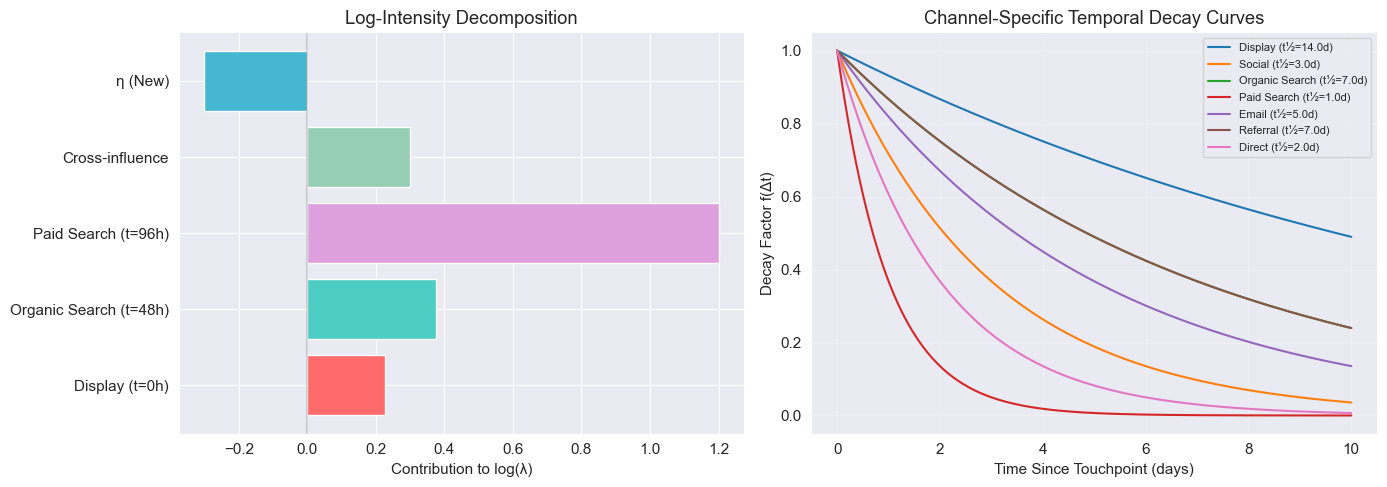

In [6]:
# 예시 여정
example_channels = ["Display", "Organic Search", "Paid Search"]
example_timestamps = [0.0, 48.0, 96.0]
observation_time = 96.0
segment_new = config.segments[0]  # New user (η=-0.3)

# 각 touchpoint의 기여 분해
channel_lookup = {ch.name: ch for ch in config.channels}
components = []

for ch_name, t_j in zip(example_channels, example_timestamps):
    ch_def = channel_lookup[ch_name]
    delta_t = observation_time - t_j
    decay = compute_temporal_decay(ch_def.decay_half_life_days, delta_t)
    contribution = ch_def.beta * decay
    components.append({
        "Touchpoint": f"{ch_name} (t={t_j:.0f}h)",
        "β": ch_def.beta,
        "Δt (hours)": delta_t,
        "Decay f(Δt)": decay,
        "β × f(Δt)": contribution,
    })

comp_df = pd.DataFrame(components)
print("=== Touchpoint별 기여 분해 ===")
print(comp_df.to_string(index=False, float_format="%.4f"))

# Cross-influence
ci_bonus = compute_cross_influence_bonus(
    example_channels, example_timestamps, observation_time,
    config.cross_influences, config.channels,
)
display_decay = compute_temporal_decay(14.0, observation_time - 0.0)  # Display at t=0, obs at 96h
print(f"\nCross-influence bonus: {ci_bonus:.4f}")
print(f"  Display→Paid Search: δ=0.4 × f_Display(96h)={display_decay:.4f} = {0.4*display_decay:.4f}")
print(f"  (source 채널의 temporal decay가 시너지에도 적용됨)")

# Full computation
log_i = compute_log_intensity(example_channels, example_timestamps, observation_time, config, segment_new)
prob = intensity_to_conversion_prob(log_i)
print(f"\nα₀ = {config.alpha_0}")
print(f"Σ(β × decay) = {sum(c['β × f(Δt)'] for c in components):.4f}")
print(f"Cross-influence = {ci_bonus:.4f}")
print(f"η (New segment) = {segment_new.eta}")
print(f"─────────────────")
print(f"log(λ) = {log_i:.4f}")
print(f"P(conversion) = {prob:.4f} ({prob:.2%})")

# 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of components
labels = [c["Touchpoint"] for c in components] + ["Cross-influence", "η (New)"]
values = [c["β × f(Δt)"] for c in components] + [ci_bonus, segment_new.eta]
colors = ["#FF6B6B", "#4ECDC4", "#DDA0DD", "#96CEB4", "#45B7D1"]
ax1.barh(labels, values, color=colors[:len(labels)])
ax1.set_xlabel("Contribution to log(λ)")
ax1.set_title("Log-Intensity Decomposition")
ax1.axvline(x=0, color="gray", linestyle="-", alpha=0.3)

# Temporal decay curves
t_range = np.linspace(0, 240, 200)  # 0~10 days
for ch_def in config.channels:
    decay_curve = [compute_temporal_decay(ch_def.decay_half_life_days, t) for t in t_range]
    ax2.plot(t_range / 24, decay_curve, label=f"{ch_def.name} (t½={ch_def.decay_half_life_days}d)")
ax2.set_xlabel("Time Since Touchpoint (days)")
ax2.set_ylabel("Decay Factor f(Δt)")
ax2.set_title("Channel-Specific Temporal Decay Curves")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. 생성 데이터 EDA

100K 유저로 생성된 데이터를 탐색한다. DGP 검증 체크리스트:
- 전환율 2~3% ✓
- 여정 길이 right-skewed ✓  
- 전환 여정에 Paid Search/Email 비율 > 비전환 ✓
- 채널 빈도 분포 현실적 ✓

=== 생성 데이터 요약 ===
총 유저: 100,000
총 터치포인트: 517,893
전환 유저: 2,305 (2.31%)
평균 여정 길이: 5.18
여정 길이 skewness: 1.783
Calibrated α₀: -5.625


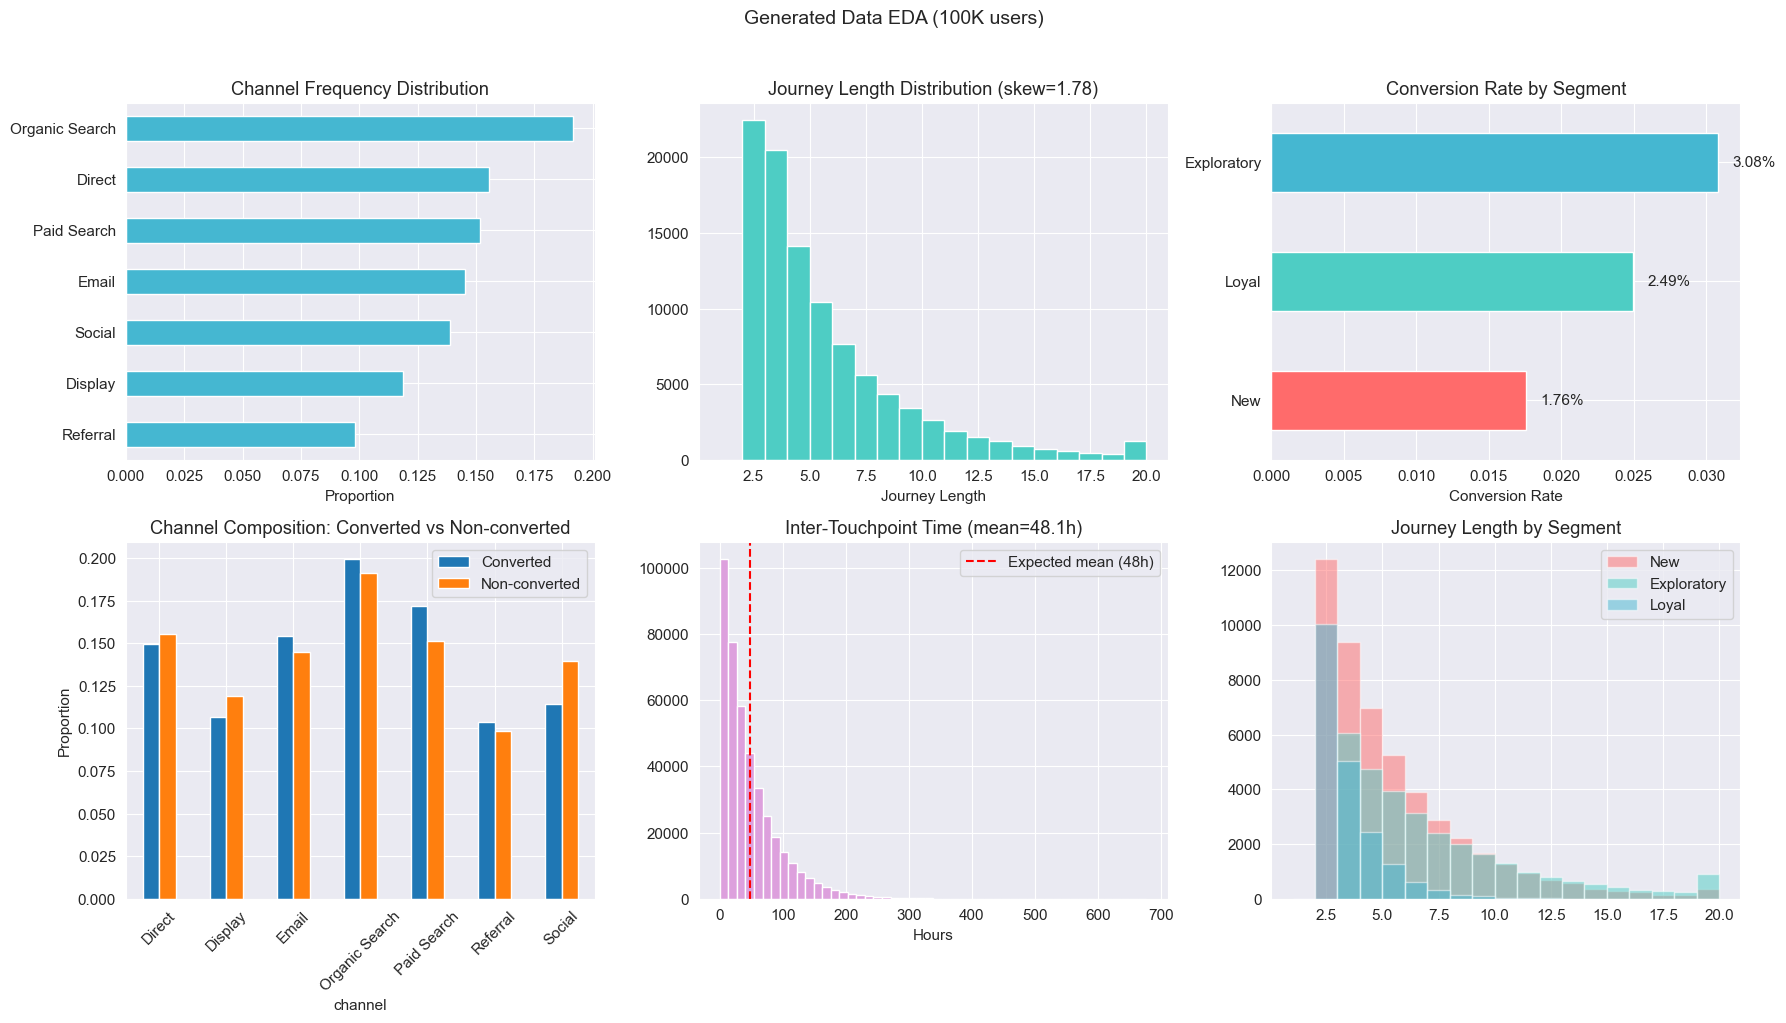

In [7]:
journeys = pd.read_parquet("../../data/simulation/journeys.parquet")
with open("../../data/simulation/summary_stats.json") as f:
    stats = json.load(f)

print(f"=== 생성 데이터 요약 ===")
print(f"총 유저: {stats['n_users']:,}")
print(f"총 터치포인트: {len(journeys):,}")
print(f"전환 유저: {stats['n_converted']:,} ({stats['conversion_rate']:.2%})")
print(f"평균 여정 길이: {stats['journey_length_mean']:.2f}")
print(f"여정 길이 skewness: {stats['journey_length_skew']:.3f}")
print(f"Calibrated α₀: {stats['calibrated_alpha_0']}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. 채널 빈도
ch_freq = pd.Series(stats["channel_frequency"]).sort_values(ascending=True)
ch_freq.plot(kind="barh", ax=axes[0, 0], color=[CATEGORY_COLORS.get("Statistical", "#45B7D1")] * 7)
axes[0, 0].set_title("Channel Frequency Distribution")
axes[0, 0].set_xlabel("Proportion")

# 2. 여정 길이 분포
user_level = journeys.groupby("user_id").agg(journey_length=("journey_length", "first"), converted=("converted", "first"), segment=("segment", "first"))
user_level["journey_length"].hist(bins=range(1, 21), ax=axes[0, 1], color="#4ECDC4", edgecolor="white")
axes[0, 1].set_title(f"Journey Length Distribution (skew={stats['journey_length_skew']:.2f})")
axes[0, 1].set_xlabel("Journey Length")

# 3. 세그먼트별 전환율
seg_rates = pd.Series(stats["conversion_rate_by_segment"]).sort_values(ascending=True)
seg_rates.plot(kind="barh", ax=axes[0, 2], color=["#FF6B6B", "#4ECDC4", "#45B7D1"])
axes[0, 2].set_title("Conversion Rate by Segment")
axes[0, 2].set_xlabel("Conversion Rate")
for i, (seg, rate) in enumerate(seg_rates.items()):
    axes[0, 2].text(rate + 0.001, i, f"{rate:.2%}", va="center")

# 4. 전환/비전환 여정의 채널 구성
conv_channels = journeys[journeys["converted"]]["channel"].value_counts(normalize=True)
nonconv_channels = journeys[~journeys["converted"]]["channel"].value_counts(normalize=True)
compare_df = pd.DataFrame({"Converted": conv_channels, "Non-converted": nonconv_channels}).fillna(0)
compare_df.plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("Channel Composition: Converted vs Non-converted")
axes[1, 0].set_ylabel("Proportion")
axes[1, 0].tick_params(axis='x', rotation=45)

# 5. 터치포인트 간 시간 간격
time_deltas = journeys.groupby("user_id")["timestamp"].diff().dropna()
time_deltas[time_deltas > 0].hist(bins=50, ax=axes[1, 1], color="#DDA0DD", edgecolor="white")
axes[1, 1].set_title(f"Inter-Touchpoint Time (mean={time_deltas[time_deltas > 0].mean():.1f}h)")
axes[1, 1].set_xlabel("Hours")
axes[1, 1].axvline(x=48, color="red", linestyle="--", label="Expected mean (48h)")
axes[1, 1].legend()

# 6. 세그먼트별 여정 길이
for seg_name, color in zip(["New", "Exploratory", "Loyal"], ["#FF6B6B", "#4ECDC4", "#45B7D1"]):
    subset = user_level[user_level["segment"] == seg_name]
    axes[1, 2].hist(subset["journey_length"], bins=range(1, 21), alpha=0.5, label=seg_name, color=color, edgecolor="white")
axes[1, 2].set_title("Journey Length by Segment")
axes[1, 2].legend()

plt.suptitle("Generated Data EDA (100K users)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Ground Truth 해석

두 가지 ground truth 정의를 비교하고, DGP 파라미터와의 관계를 분석한다:

- **Ground Truth A (Intensity Decomposition):** 전환 유저의 log-intensity를 채널별로 분해. 실제 전환 메커니즘에서의 기여.
- **Ground Truth B (Counterfactual Shapley):** 128개 coalition에 대해 반사실적 전환율을 계산한 Shapley value.

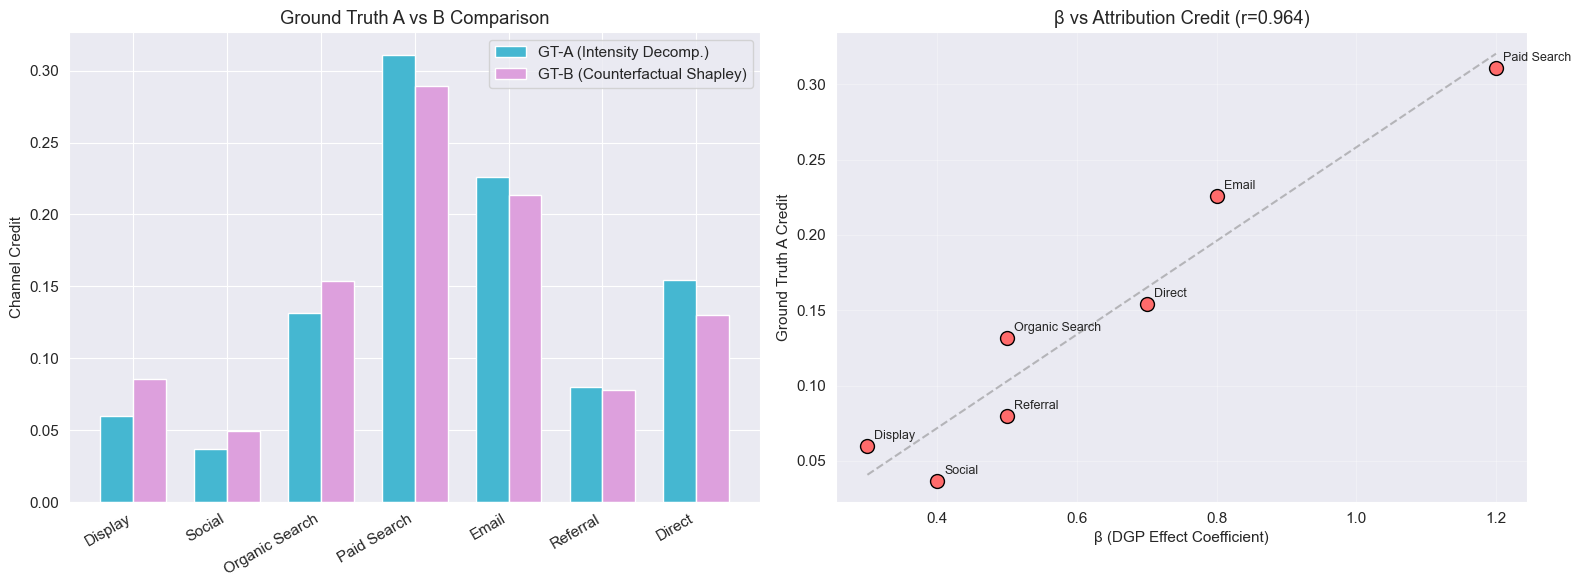

→ β와 Ground Truth Credit의 상관은 높지만 완벽하지 않다 (r≠1.0).
  이는 temporal decay, channel frequency, cross-influence가 최종 기여에 영향을 미치기 때문.
  예: Display는 β=0.3으로 cross-influence 시너지 credit의 20%만 배분받고 (β-비례),
      Paid Search는 β=1.2로 시너지 credit의 80%를 가져간다.
      또한 source 채널의 temporal decay가 시너지에도 적용되어 Display credit이 추가 감소.


In [8]:
with open("../../data/simulation/ground_truth.json") as f:
    gt = json.load(f)

gt_a = gt["ground_truth_A"]["channel_credits"]
gt_b = gt["ground_truth_B"]["channel_credits"]
betas = gt["dgp_parameters"]["betas"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# GT-A vs GT-B 비교
channels = list(gt_a.keys())
x = np.arange(len(channels))
width = 0.35
ax1.bar(x - width/2, [gt_a[c] for c in channels], width, label="GT-A (Intensity Decomp.)", color="#45B7D1")
ax1.bar(x + width/2, [gt_b[c] for c in channels], width, label="GT-B (Counterfactual Shapley)", color="#DDA0DD")
ax1.set_xticks(x)
ax1.set_xticklabels(channels, rotation=30, ha="right")
ax1.set_ylabel("Channel Credit")
ax1.set_title("Ground Truth A vs B Comparison")
ax1.legend()

# β vs Ground Truth 상관
beta_vals = [betas[c] for c in channels]
gt_a_vals = [gt_a[c] for c in channels]
ax2.scatter(beta_vals, gt_a_vals, s=100, c="#FF6B6B", edgecolor="black", zorder=3)
for c, bv, gv in zip(channels, beta_vals, gt_a_vals):
    ax2.annotate(c, (bv, gv), textcoords="offset points", xytext=(5, 5), fontsize=9)

# Trend line
z = np.polyfit(beta_vals, gt_a_vals, 1)
p = np.poly1d(z)
x_line = np.linspace(min(beta_vals), max(beta_vals), 100)
ax2.plot(x_line, p(x_line), "--", color="gray", alpha=0.5)
corr = np.corrcoef(beta_vals, gt_a_vals)[0, 1]
ax2.set_xlabel("β (DGP Effect Coefficient)")
ax2.set_ylabel("Ground Truth A Credit")
ax2.set_title(f"β vs Attribution Credit (r={corr:.3f})")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("→ β와 Ground Truth Credit의 상관은 높지만 완벽하지 않다 (r≠1.0).")
print("  이는 temporal decay, channel frequency, cross-influence가 최종 기여에 영향을 미치기 때문.")
print(f"  예: Display는 β=0.3으로 cross-influence 시너지 credit의 20%만 배분받고 (β-비례),")
print(f"      Paid Search는 β=1.2로 시너지 credit의 80%를 가져간다.")
print(f"      또한 source 채널의 temporal decay가 시너지에도 적용되어 Display credit이 추가 감소.")

---
## 요약

1. **공개 MTA 데이터셋의 한계**를 정확히 진단하고, 해석 가능한 시뮬레이션을 설계
2. **3개 학술 프레임워크를 통합**한 DGP: Du et al.(구조) + Shender et al.(시간감쇠) + CDA(상호작용)
3. **100K 유저, 7채널, 2.31% 전환율**의 현실적 데이터 생성 (right-skewed 여정, 퍼널 진행 패턴)
4. **Ground Truth**는 β 값만이 아닌 decay, frequency, cross-influence의 복합 함수
5. **세그먼트 구조가 confounding을 생성** → Causal 방법론의 필요성 근거

다음 노트북: [02_traditional_methods.ipynb](02_traditional_methods.ipynb) — Rule-based, Markov, Shapley

---

🧭 **노트북 흐름**: 01 DGP → **02 Main(Survival/IncShap/Multi-Path)** → 03 Benchmark Traditional → 04 Benchmark DL → 05 Benchmark Causal → 06 Benchmark Comparison → 07 Cost/Budget → 08 Real-World Validation → Part 2

—  |  [02 Main 방법론 →](02_main_survival_incremental_shapley.ipynb)
